Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
standard_model_path = Path.cwd().parent.parent / "results" / "standard_model_summary.csv"
standard_model_df = pd.read_csv(standard_model_path, low_memory=False)

cardiac_believing_path = Path.cwd().parent.parent / "results" / "cardiac_believing_summary.csv"
cardiac_believing_df = pd.read_csv(cardiac_believing_path, low_memory=False)

Dynamic beliefs
           n         r        CI95%         p-val       BF10  power
pearson  187  0.500596  [0.38, 0.6]  2.970392e-13  2.677e+10    1.0
Static beliefs
           n         r         CI95%         p-val       BF10  power
pearson  187  0.566432  [0.46, 0.66]  2.930368e-17  2.187e+14    1.0


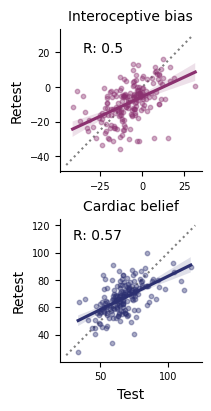

In [9]:
fig, axs = plt.subplots(figsize=(2, 4), nrows=2)

merged = pd.merge(
    standard_model_df[standard_model_df.session == 1],
    standard_model_df[standard_model_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

sns.regplot(
    x=merged["intero_threshold_del1"],
    y=merged["intero_threshold_del2"],
    scatter_kws={"s": 10, "alpha": .4},
    color="#8b3170",
    ax=axs[0]
)
axs[0].annotate(
    f"R: {round(pg.corr(
    x=merged["intero_threshold_del1"].to_numpy(),
    y=merged["intero_threshold_del2"].to_numpy(),
).r.iloc[0], 2)}",
    (-35, 20)
)

print("Dynamic beliefs")
print(
    pg.corr(
        x=merged["intero_threshold_del1"].to_numpy(),
        y=merged["intero_threshold_del2"].to_numpy(),
    )
)

merged = pd.merge(
    cardiac_believing_df[cardiac_believing_df.session == 1],
    cardiac_believing_df[cardiac_believing_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

sns.regplot(
    x=merged["intero_mean_del1"],
    y=merged["intero_mean_del2"],
    color="#2c3071",
    scatter_kws={"s": 10, "alpha": .4},
    ax=axs[1]
)
axs[1].annotate(
    f"R: {round(pg.corr(
    x=merged["intero_mean_del1"].to_numpy(),
    y=merged["intero_mean_del2"].to_numpy(),
).r.iloc[0], 2)}",
    (30, 110)
)

print("Static beliefs")
print(
    pg.corr(
        x=merged["intero_mean_del1"].to_numpy(),
        y=merged["intero_mean_del2"].to_numpy(),
    )
)

axs[0].plot((-45, 30), (-45, 30), linestyle=":", color="gray", zorder=0)
axs[0].tick_params(axis='both', labelsize=7)
axs[0].set_title("Interoceptive bias", fontsize=10)
axs[1].plot((25, 120), (25, 120), linestyle=":", color="gray", zorder=0)
axs[1].tick_params(axis='both', labelsize=7)
axs[1].set_title("Cardiac belief", fontsize=10)

axs[0].set(xlabel=None, ylabel="Retest")
axs[1].set(xlabel="Test", ylabel="Retest")

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_reliability.svg")